In [39]:
import pandas as pd
import numpy as np
import sklearn
import pandas as pd


In [40]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:

df = pd.read_csv('/content/drive/MyDrive/Heart disease dataset/Heart Disease.csv')

# Display first few rows
df.head()



,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart Disease (in next 10 years)
0,Male,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,Female,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,Male,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,Female,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,Female,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [42]:
df.shape

(4240, 16)

In [43]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gender                            4240 non-null   object 
 1   age                               4240 non-null   int64  
 2   education                         4135 non-null   float64
 3   currentSmoker                     4240 non-null   int64  
 4   cigsPerDay                        4211 non-null   float64
 5   BPMeds                            4187 non-null   float64
 6   prevalentStroke                   4240 non-null   int64  
 7   prevalentHyp                      4240 non-null   int64  
 8   diabetes                          4240 non-null   int64  
 9   totChol                           4190 non-null   float64
 10  sysBP                             4240 non-null   float64
 11  diaBP                             4240 non-null   float64
 12  BMI   

,0
gender,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [44]:
# Encode gender: Male → 1, Female → 0
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})



In [45]:
# Fill missing values for each column using the median
df['education'] = df['education'].fillna(df['education'].median())
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].median())
df['totChol'] = df['totChol'].fillna(df['totChol'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['heartRate'] = df['heartRate'].fillna(df['heartRate'].median())
df['glucose'] = df['glucose'].fillna(df['glucose'].median())




# Print a quick summary of missing values after this:
print(df.isnull().sum())

gender                              0
age                                 0
education                           0
currentSmoker                       0
cigsPerDay                          0
BPMeds                              0
prevalentStroke                     0
prevalentHyp                        0
diabetes                            0
totChol                             0
sysBP                               0
diaBP                               0
BMI                                 0
heartRate                           0
glucose                             0
Heart Disease (in next 10 years)    0
dtype: int64


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Feature Encoding (already done earlier for 'gender')

# Step 2: Define features (X) and target (y)
X = df.drop(columns=['Heart Disease (in next 10 years)'])
y = df['Heart Disease (in next 10 years)']

# Step 3: Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Feature Scaling (Standardize the features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Now, X_train_scaled and X_test_scaled are ready for model training


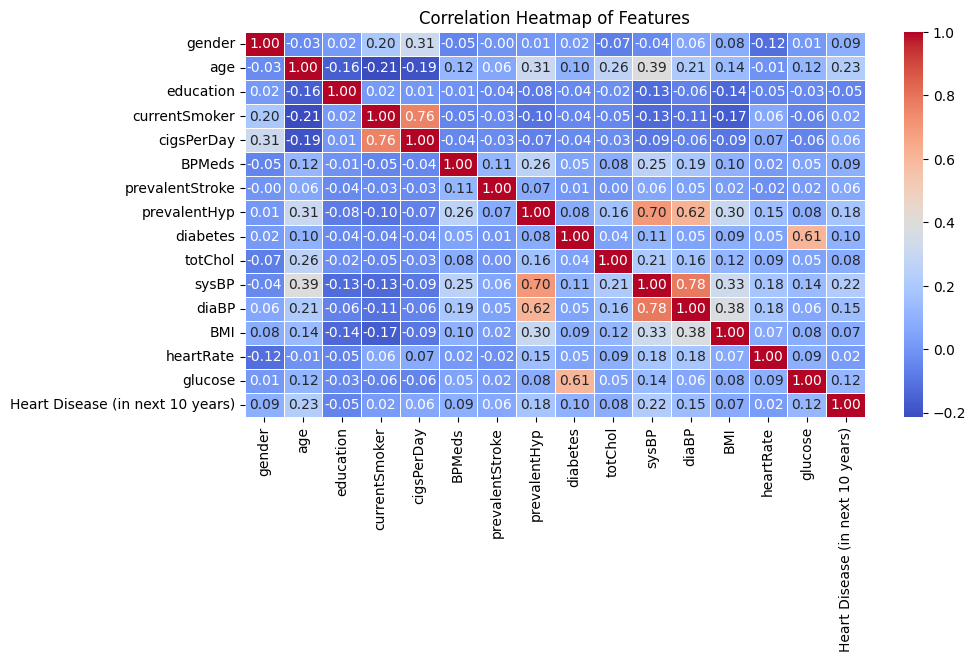

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Compute the correlation matrix
correlation_matrix = df.corr()

# Step 2: Plot the heatmap
plt.figure(figsize=(10,5))  # Set the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Display the heatmap
plt.title("Correlation Heatmap of Features")
plt.show()


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Initialize the Logistic Regression model
model = LogisticRegression()

# Step 2: Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

# Step 3: Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Step 4: Evaluate the model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 0.8550

Confusion Matrix:
[[717   8]
 [115   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       725
           1       0.50      0.07      0.12       123

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.81      0.85      0.80       848



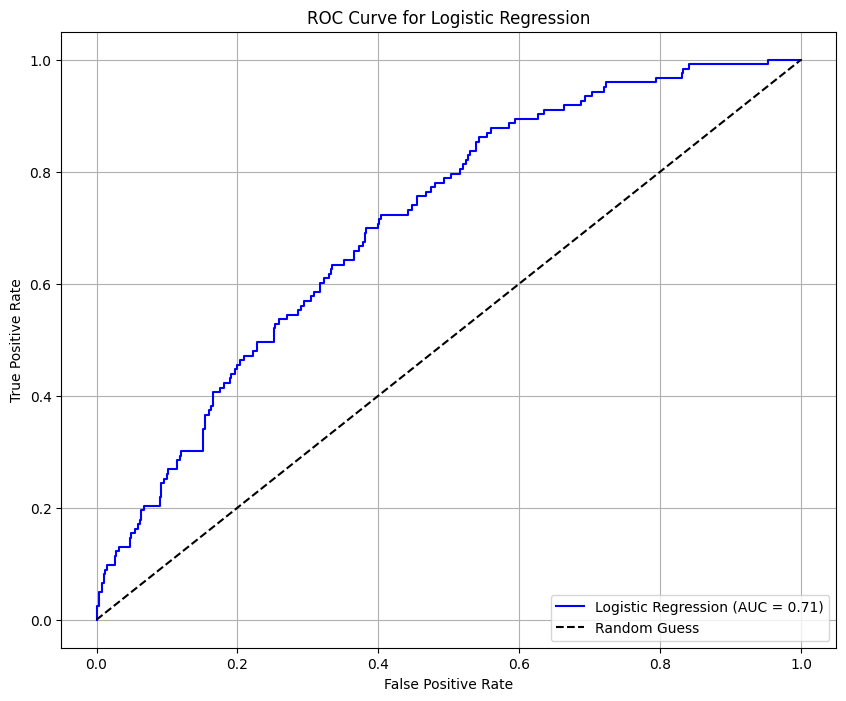

AUC: 0.7089


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Impute missing values with the mean (you can also use median or most_frequent)
imputer = SimpleImputer(strategy='mean')
X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)
X_test_scaled_imputed = imputer.transform(X_test_scaled)

# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled_imputed, y_train)

# Predict probabilities for class 1 (positive class)
y_probs = model.predict_proba(X_test_scaled_imputed)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print the AUC value
print(f"AUC: {roc_auc:.4f}")


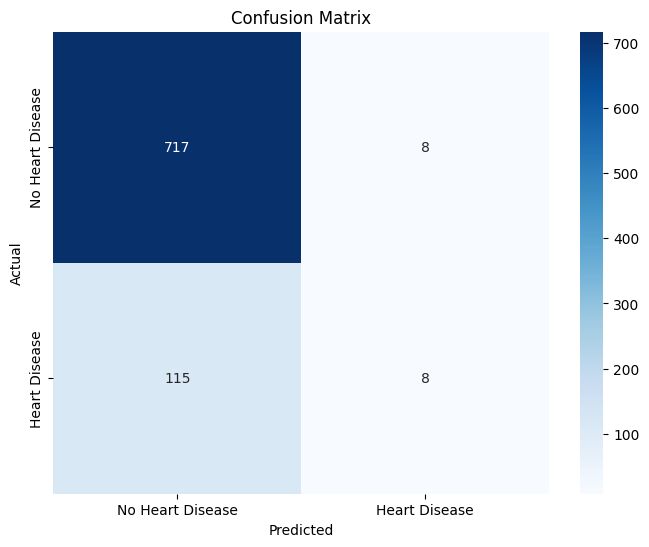

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=['No Heart Disease', 'Heart Disease'], yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

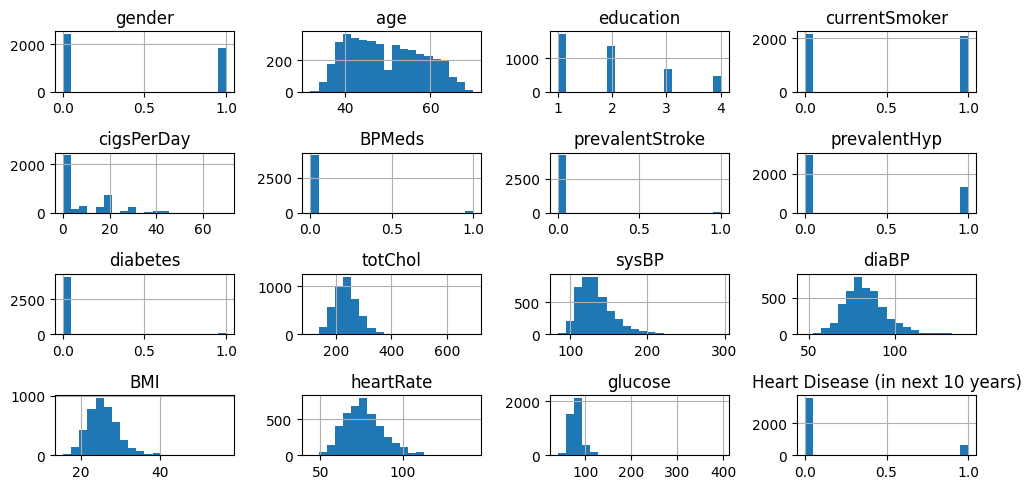

In [50]:
import matplotlib.pyplot as plt

# Plot histograms for all numeric columns
df.hist(figsize=(10, 5), bins=20)
plt.tight_layout()
plt.show()


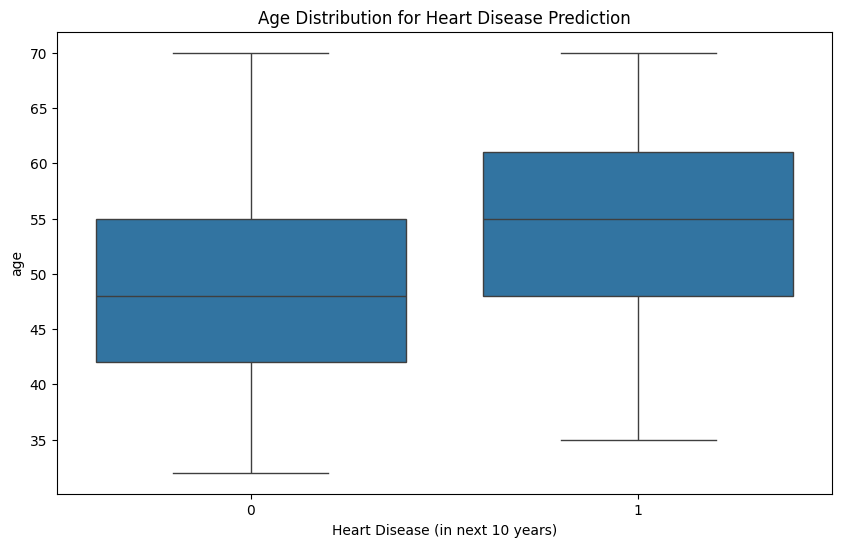

In [51]:
import seaborn as sns

# Create a boxplot for a specific feature
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Heart Disease (in next 10 years)', y='age')
plt.title('Age Distribution for Heart Disease Prediction')
plt.show()


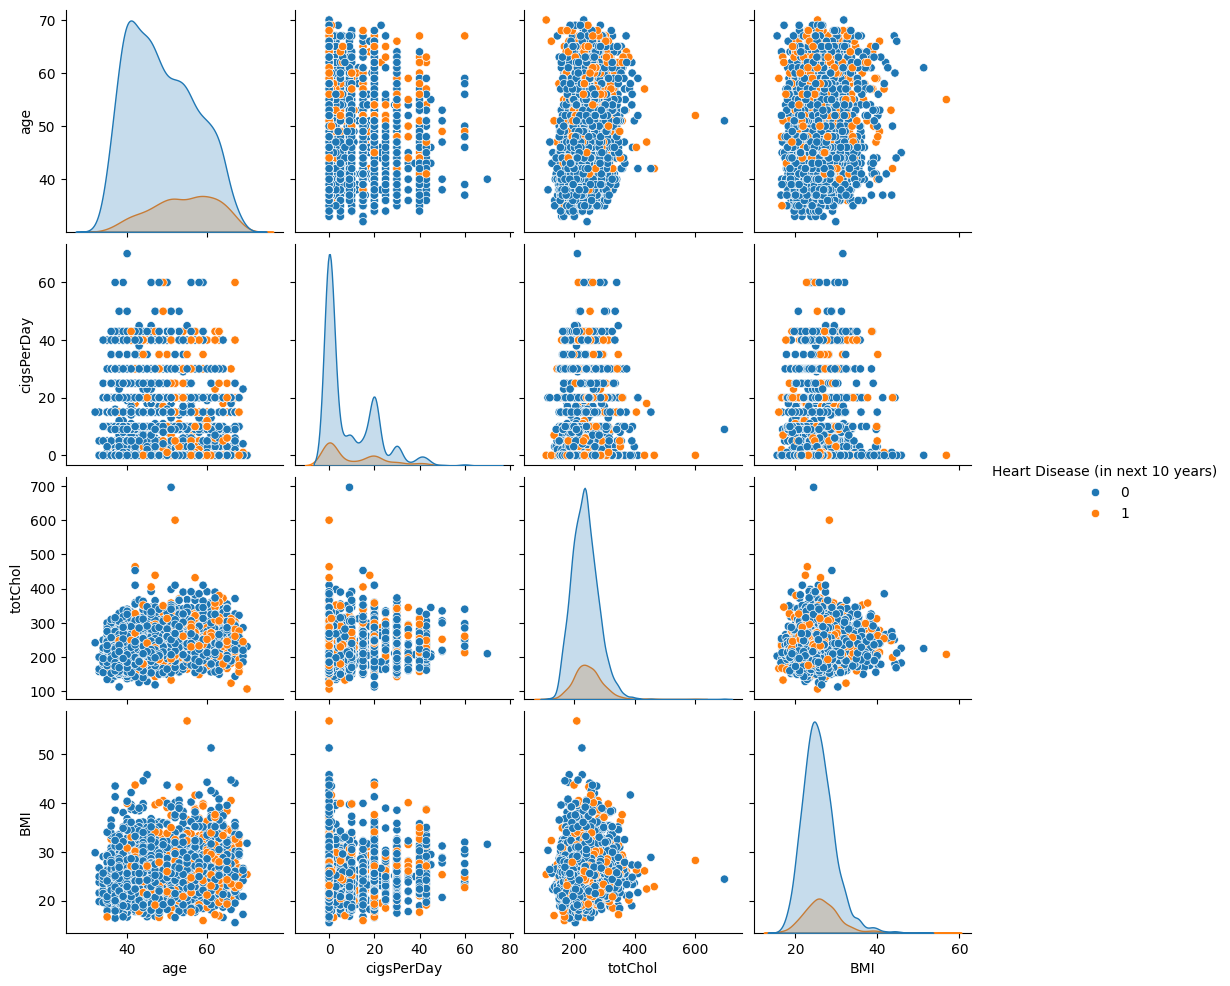

In [52]:
# Create a pairplot
sns.pairplot(df, hue='Heart Disease (in next 10 years)', vars=['age', 'cigsPerDay', 'totChol', 'BMI'])
plt.show()



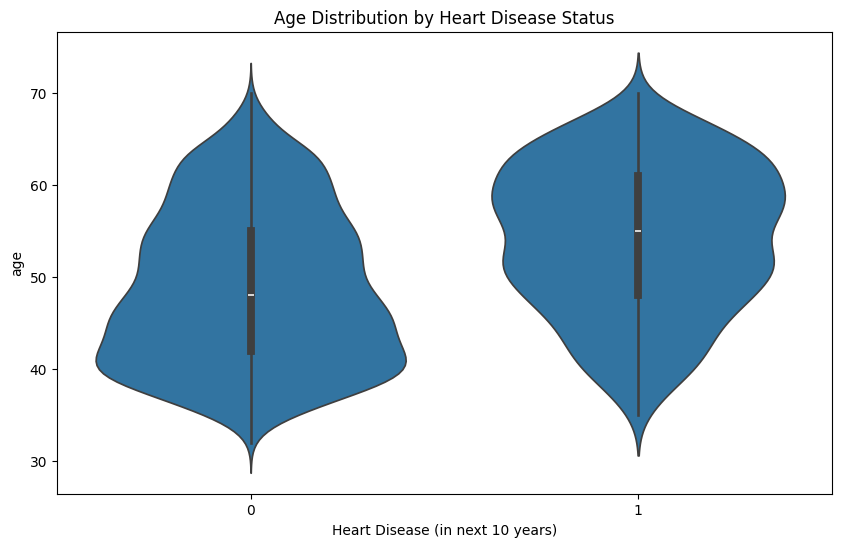

In [53]:
# Violin plot for age distribution by heart disease status
plt.figure(figsize=(10, 6))
sns.violinplot(x='Heart Disease (in next 10 years)', y='age', data=df)
plt.title('Age Distribution by Heart Disease Status')
plt.show()


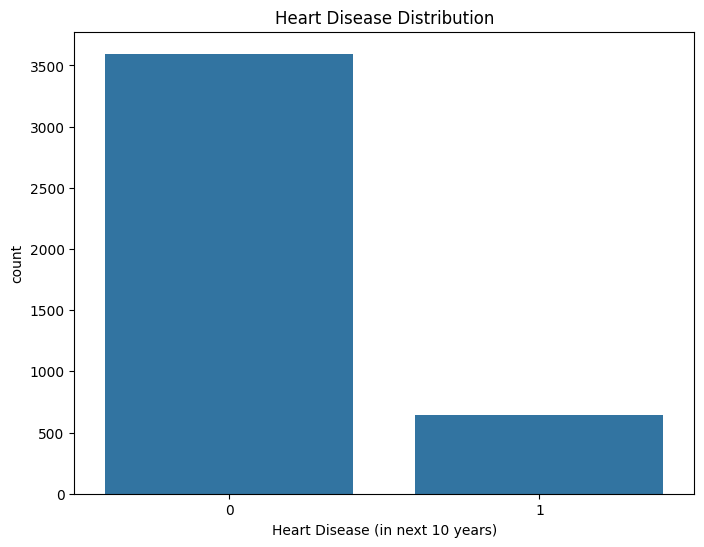

In [54]:
# Plot the distribution of the target variable (Heart Disease)
plt.figure(figsize=(8, 6))
sns.countplot(x='Heart Disease (in next 10 years)', data=df)
plt.title('Heart Disease Distribution')
plt.show()


In [55]:
!pip install xgboost

In [56]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Train XGBoost Model
# Convert your data into DMatrix format (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# Define parameters for XGBoost
params = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'logloss',        # Log loss (cross-entropy) as evaluation metric
    'max_depth': 6,                  # Maximum depth of trees
    'eta': 0.1,                      # Learning rate
    'subsample': 0.8,                # Subsample ratio of the training data
    'colsample_bytree': 0.8         # Subsample ratio of features per tree
}

# Step 3: Train the model
num_round = 100  # Number of boosting rounds (iterations)
bst = xgb.train(params, dtrain, num_round)

# Step 4: Make predictions
y_pred = bst.predict(dtest)
y_pred_binary = [1 if i >= 0.5 else 0 for i in y_pred]  # Convert probabilities to binary

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary))




Accuracy: 0.8502358490566038
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       725
           1       0.41      0.07      0.12       123

    accuracy                           0.85       848
   macro avg       0.64      0.53      0.52       848
weighted avg       0.80      0.85      0.80       848



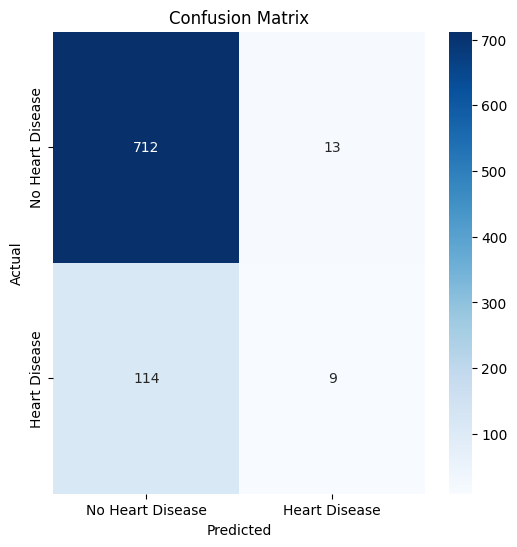

In [57]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Disease', 'Heart Disease'], yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

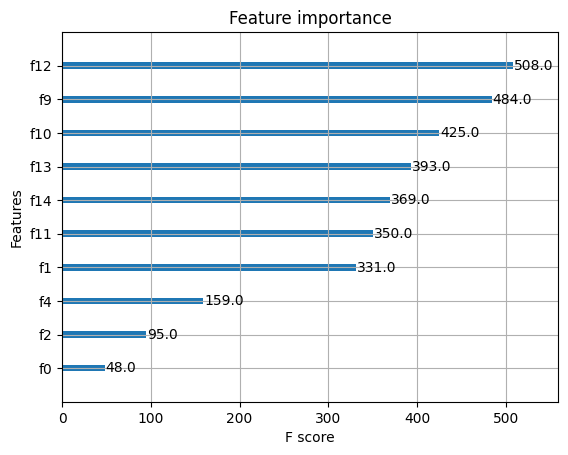

In [58]:

# Step 6: Plot Feature Importance (optional)
xgb.plot_importance(bst, importance_type='weight', max_num_features=10)
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:46:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


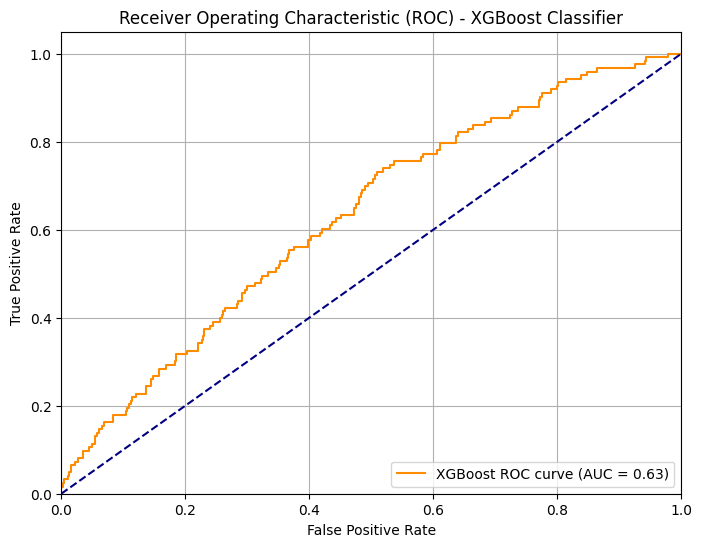

In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Train the XGBoost Classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_scaled, y_train)

# Step 2: Predict probabilities
y_probs = xgb_clf.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

# Step 3: Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Step 4: Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'XGBoost ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - XGBoost Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


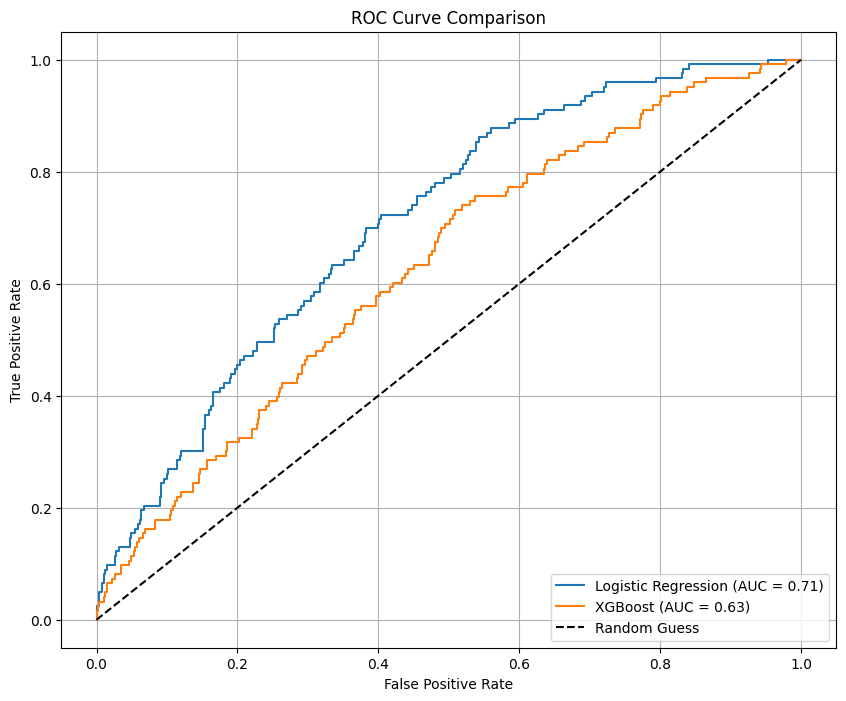

In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming models is a dictionary where model names are keys and models are values
models = {
    "Logistic Regression": LogisticRegression(),
    "XGBoost": XGBClassifier(),
    # Add any other models you want to compare
}

plt.figure(figsize=(10, 8))

# Iterate through each model in the dictionary
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict probabilities for class 1 (positive class)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line (representing random guessing)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()
